# Classifier artifact assessment

Load one saved classifier, inspect its training history, reconstruct its deterministic test split, and calculate masked multilabel evaluation curves.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "artifacts").exists():
    ROOT = ROOT.parent
if not (ROOT / "artifacts").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory")
sys.path.insert(0, str(ROOT))

from src.data import fit_standardizer, make_dataset, split_indices
from src.hashing import calculate_run_id
from src.model import build_model
from src.training import build_loss

## Select and load one artifact

In [3]:
PROJECT_BASENAME = "bmra_student_project"
RUN_ID = "b5874d285eb0"

artifact_dir = ROOT / "artifacts" / PROJECT_BASENAME / RUN_ID
required_files = {
    "model.pt",
    "framework.yaml",
    f"{PROJECT_BASENAME}.yaml",
    "metrics.json",
    "training_history.csv",
}
missing_files = [name for name in required_files if not (artifact_dir / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing artifact files in {artifact_dir}: {missing_files}")
artifact_dir

PosixPath('/media/chnguyen47/ADATA/Projects/BMRA_modular_MLC/artifacts/bmra_student_project/b5874d285eb0')

In [4]:
framework = yaml.safe_load((artifact_dir / "framework.yaml").read_bytes())
project = yaml.safe_load((artifact_dir / f"{PROJECT_BASENAME}.yaml").read_bytes())
history = pd.read_csv(artifact_dir / "training_history.csv")
metrics = json.loads((artifact_dir / "metrics.json").read_text(encoding="utf-8"))

resolved_config = {**framework, "project": {**framework["project"], **project}}
calculated_run_id = calculate_run_id(resolved_config)
if calculated_run_id != RUN_ID:
    raise ValueError(f"Artifact/config hash mismatch: {RUN_ID} != {calculated_run_id}")

summary = pd.Series(
    {
        "project": PROJECT_BASENAME,
        "run_id": RUN_ID,
        "features": len(project["features"]),
        "labels": len(project["labels"]),
        "epochs_trained": len(history),
        "best_epoch": metrics.get("best_epoch"),
        "stopped_early": metrics.get("stopped_early"),
    },
    name="value",
)
display(summary, pd.DataFrame(metrics.get("test", {}), index=["saved_test"]))

project           bmra_student_project
run_id                    b5874d285eb0
features                           307
labels                              76
epochs_trained                      25
best_epoch                          15
stopped_early                     True
Name: value, dtype: object

,accuracy,loss,micro_f1
saved_test,0.950601,0.139165,0.082192


## Training history

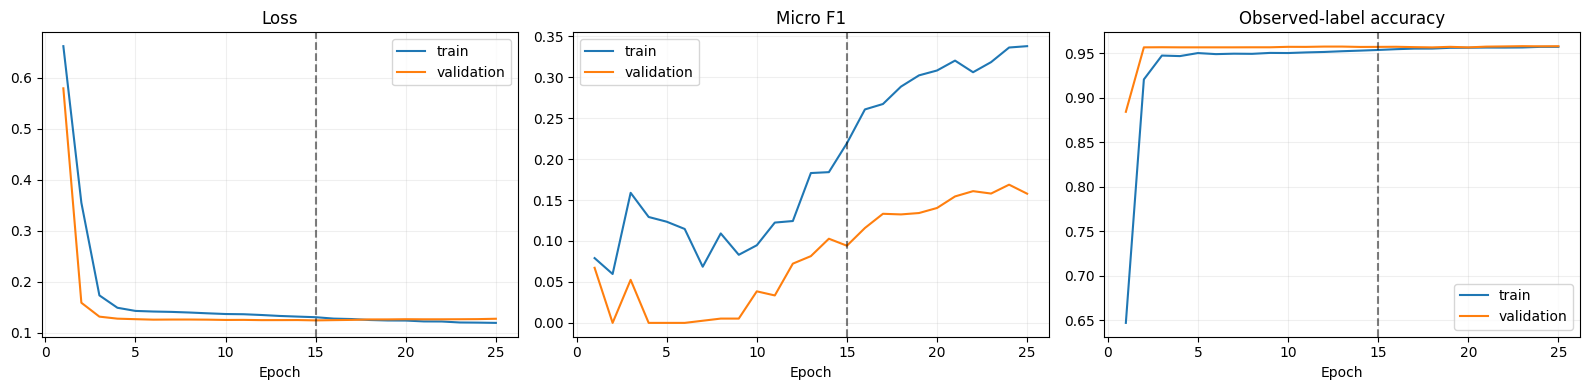

,epoch,train_accuracy,train_micro_f1,train_loss,val_accuracy,val_micro_f1,val_loss
20,21,0.956340,0.320183,0.122377,0.957380,0.154370,0.126501
21,22,0.956304,0.305988,0.122222,0.957609,0.160815,0.126517
22,23,0.956438,0.318330,0.120275,0.957895,0.157895,0.126643
23,24,0.957124,0.336176,0.120003,0.957723,0.168729,0.126866
24,25,0.957148,0.337810,0.119494,0.957838,0.157714,0.127604


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, metric, title in zip(
    axes, ["loss", "micro_f1", "accuracy"], ["Loss", "Micro F1", "Observed-label accuracy"]
):
    axis.plot(history["epoch"], history[f"train_{metric}"], label="train")
    axis.plot(history["epoch"], history[f"val_{metric}"], label="validation")
    if metrics.get("best_epoch") is not None:
        axis.axvline(metrics["best_epoch"], color="black", linestyle="--", alpha=0.5)
    axis.set(title=title, xlabel="Epoch")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()
history.tail()

## Reconstruct the test split and run inference

In [6]:
data_path = ROOT / framework["data"]["path"]
frame = pd.read_parquet(data_path)
feature_columns = project["features"]
label_columns = project["labels"]
missing_columns = set(feature_columns + label_columns) - set(frame.columns)
if missing_columns:
    raise ValueError(f"Columns missing from evaluation data: {sorted(missing_columns)}")

split = framework["split"]
train_idx, _, test_idx = split_indices(
    len(frame), split["train"], split["val"], split["test"], split["seed"]
)
means, scales = fit_standardizer(frame.iloc[train_idx], feature_columns)
test_data = make_dataset(frame.iloc[test_idx], feature_columns, label_columns, means, scales)
test_loader = DataLoader(test_data, batch_size=framework["training"]["batch_size"])
len(test_data)

232

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(framework, project).to(device)
model.load_state_dict(torch.load(artifact_dir / "model.pt", map_location=device, weights_only=True))
model.eval()
criterion = build_loss(framework["loss"]).to(device)

all_logits, all_targets, all_masks = [], [], []
with torch.no_grad():
    for features, targets, feature_mask, label_mask in test_loader:
        logits = model(features.to(device), feature_mask.to(device))
        all_logits.append(logits.cpu())
        all_targets.append(targets)
        all_masks.append(label_mask)

logits = torch.cat(all_logits)
targets = torch.cat(all_targets)
availability = torch.cat(all_masks).bool()
probabilities = torch.sigmoid(logits)
predictions = probabilities >= 0.5
test_loss = criterion(logits, targets, availability).item()
logits.shape, test_loss

(torch.Size([232, 76]), 0.13916495442390442)

## Common masked multilabel metrics

In [8]:
target_array = targets.numpy().astype(int)
probability_array = probabilities.numpy()
prediction_array = predictions.numpy().astype(int)
mask_array = availability.numpy()

per_label_rows = []
for index, label in enumerate(label_columns):
    observed = mask_array[:, index]
    y_true = target_array[observed, index]
    y_score = probability_array[observed, index]
    y_pred = prediction_array[observed, index]
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    has_both_classes = len(np.unique(y_true)) == 2
    per_label_rows.append(
        {
            "label": label,
            "support": len(y_true),
            "positive_count": int(y_true.sum()),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc_score(y_true, y_score) if has_both_classes else np.nan,
            "average_precision": (
                average_precision_score(y_true, y_score) if has_both_classes else np.nan
            ),
        }
    )
per_label = pd.DataFrame(per_label_rows).set_index("label")

flat_targets = target_array[mask_array]
flat_scores = probability_array[mask_array]
flat_predictions = prediction_array[mask_array]
micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
    flat_targets, flat_predictions, average="binary", zero_division=0
)
row_has_labels = mask_array.any(axis=1)
row_correct = ((prediction_array == target_array) | ~mask_array).all(axis=1)

evaluation = pd.Series(
    {
        "masked_bce": test_loss,
        "observed_accuracy": (flat_predictions == flat_targets).mean(),
        "subset_accuracy": row_correct[row_has_labels].mean(),
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "macro_precision": per_label["precision"].mean(),
        "macro_recall": per_label["recall"].mean(),
        "macro_f1": per_label["f1"].mean(),
        "micro_roc_auc": roc_auc_score(flat_targets, flat_scores),
        "macro_roc_auc": per_label["roc_auc"].mean(),
        "micro_average_precision": average_precision_score(flat_targets, flat_scores),
        "macro_average_precision": per_label["average_precision"].mean(),
    },
    name="value",
)
saved_comparison = pd.DataFrame(
    {
        "saved": {
            "masked_bce": metrics["test"]["loss"],
            "observed_accuracy": metrics["test"]["accuracy"],
            "micro_f1": metrics["test"]["micro_f1"],
        },
        "recomputed": evaluation,
    }
).dropna()
display(
    evaluation.to_frame(),
    saved_comparison,
    per_label.sort_values("positive_count", ascending=False).head(20),
)

,value
masked_bce,0.139165
observed_accuracy,0.950601
subset_accuracy,0.280172
micro_precision,0.481481
micro_recall,0.044931
micro_f1,0.082192
macro_precision,0.049288
macro_recall,0.007720
macro_f1,0.012789
micro_roc_auc,0.893613


,saved,recomputed
masked_bce,0.139165,0.139165
micro_f1,0.082192,0.082192
observed_accuracy,0.950601,0.950601


,support,positive_count,precision,recall,f1,roc_auc,average_precision
label,,,,,,,
Magnesium Glycinate,232,101,0.520000,0.128713,0.206349,0.522976,0.478837
Omega 3,232,87,0.437500,0.080460,0.135922,0.537693,0.409381
Curcuma,232,70,0.444444,0.057143,0.101266,0.628704,0.397508
Collagen,232,55,0.000000,0.000000,0.000000,0.525372,0.251765
Lumbar Mobility,232,54,0.300000,0.055556,0.093750,0.528818,0.271230
Neck Mobility,232,52,0.428571,0.057692,0.101695,0.549252,0.294315
HVLA,232,45,0.615385,0.177778,0.275862,0.815152,0.555213
Vitamin B,232,42,0.000000,0.000000,0.000000,0.500627,0.204064
ART,232,34,1.000000,0.029412,0.057143,0.819444,0.460840


## Test ROC curves

Plot micro and macro ROC summaries plus the top-N labels ranked by individual ROC-AUC.

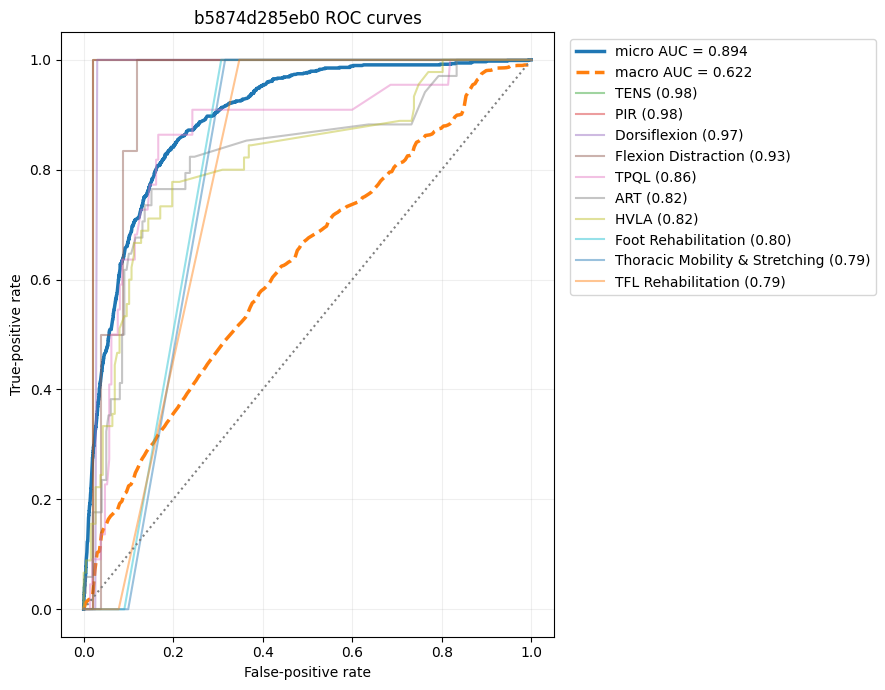

In [9]:
TOP_N_AUC_LABELS = 10
top_auc_labels = per_label.dropna(subset=["roc_auc"]).nlargest(
    TOP_N_AUC_LABELS, "roc_auc"
)

micro_fpr, micro_tpr, _ = roc_curve(flat_targets, flat_scores)
mean_fpr = np.linspace(0, 1, 200)
interpolated_tprs = []
for index, label in enumerate(label_columns):
    observed = mask_array[:, index]
    y_true = target_array[observed, index]
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, probability_array[observed, index])
    interpolated_tprs.append(np.interp(mean_fpr, fpr, tpr))
mean_tpr = np.mean(interpolated_tprs, axis=0)
mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
macro_curve_auc = auc(mean_fpr, mean_tpr)

fig, axis = plt.subplots(figsize=(9, 7))
axis.plot(micro_fpr, micro_tpr, linewidth=2.5, label=f"micro AUC = {evaluation['micro_roc_auc']:.3f}")
axis.plot(mean_fpr, mean_tpr, linestyle="--", linewidth=2.5, label=f"macro AUC = {macro_curve_auc:.3f}")
for label in top_auc_labels.index:
    index = label_columns.index(label)
    observed = mask_array[:, index]
    fpr, tpr, _ = roc_curve(target_array[observed, index], probability_array[observed, index])
    axis.plot(fpr, tpr, alpha=0.45, label=f"{label} ({per_label.loc[label, 'roc_auc']:.2f})")
axis.plot([0, 1], [0, 1], color="grey", linestyle=":")
axis.set(xlabel="False-positive rate", ylabel="True-positive rate", title=f"{RUN_ID} ROC curves")
axis.grid(alpha=0.2)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Test precision-recall curves

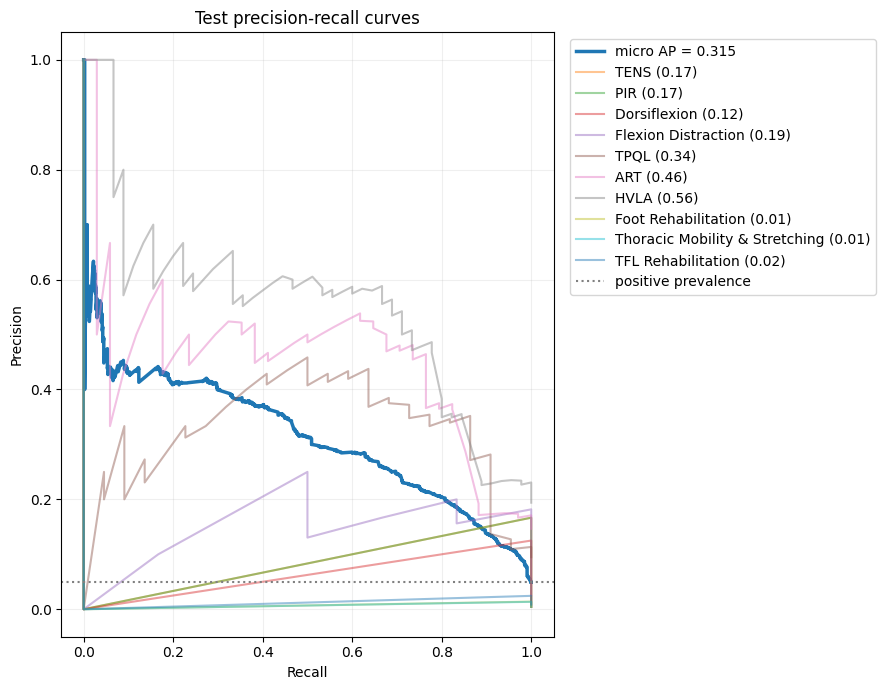

In [10]:
micro_precision_curve, micro_recall_curve, _ = precision_recall_curve(
    flat_targets, flat_scores
)
fig, axis = plt.subplots(figsize=(9, 7))
axis.plot(
    micro_recall_curve,
    micro_precision_curve,
    linewidth=2.5,
    label=f"micro AP = {evaluation['micro_average_precision']:.3f}",
)
for label in top_auc_labels.index:
    index = label_columns.index(label)
    observed = mask_array[:, index]
    precision_curve, recall_curve, _ = precision_recall_curve(
        target_array[observed, index], probability_array[observed, index]
    )
    axis.plot(
        recall_curve,
        precision_curve,
        alpha=0.45,
        label=f"{label} ({per_label.loc[label, 'average_precision']:.2f})",
    )
axis.axhline(flat_targets.mean(), color="grey", linestyle=":", label="positive prevalence")
axis.set(xlabel="Recall", ylabel="Precision", title="Test precision-recall curves")
axis.grid(alpha=0.2)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()